# TimeGAN v11

## Diagnóstico de v9 y v10

**v9** (gamma=0.1, D lr bajo): cayó en **dead equilibrium** — G=0.817 y D=1.453 fijos
durante 1500 épocas. El discriminador aprendió a decir REAL para todo porque no tenía
señal suficiente. No es Nash, es un punto muerto.

**v10** (gamma=0.5, GP+cuDNN desactivado): G convergió exactamente al Nash (1.3952 vs
1.3863 ✅), pero dos problemas nuevos:
1. **8 horas de entrenamiento** — causado por `with torch.backends.cudnn.flags(enabled=False)`
   dentro del loop del discriminador + `create_graph=True` en el gradient penalty.
   Esto fuerza `torch.autograd.grad` a ejecutarse sin cuDNN, efectivamente en CPU.
2. **Mode collapse parcial** — los sintéticos forman arcos densos en t-SNE mientras
   los reales tienen múltiples clusters. Con solo 3784 ventanas (stride=5), el generador
   aprende un subespacio, no la distribución completa.

## Cambios en v11

| | v10 | v11 |
|---|---|---|
| Stride TimeGAN | 5 (3784 ventanas) | **2 (~9500 ventanas)** |
| Regularización D | GP + cudnn desactivado (8h) | **Instance noise σ=0.05** (~20 min) |
| gamma | 0.5 | **0.5** ✓ mantenido |
| D_STEPS | 2 | **1** (D_STEPS=2 con GP causaba el D débil) |
| G_STEPS | 2 | **2** ✓ mantenido |
| LR scheduler | ReduceLROnPlateau | **Sin scheduler** (causó dead eq. en v9) |
| Feature matching | ✅ | **✅ mantenido** |
| no_grad en h_sup | ✅ | **✅ mantenido** |

**Por qué instance noise en lugar de GP:**  
El gradient penalty requiere `create_graph=True` para backprop a través de gradientes,
que es inherentemente lento. Instance noise añade `N(0, σ)` a las entradas del
discriminador — mismo efecto de regularización, sin coste computacional.
Con σ que decrece de 0.1 a 0.01 durante el entrenamiento, el discriminador aprende
estructura en lugar de memorizar patrones exactos.


In [1]:
import json
import joblib
import random
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import QuantileTransformer, StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader


In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [3]:
PROJECT_ROOT = Path("..").resolve()

with open(PROJECT_ROOT / "models" / "detectors" / "conv1d_hybrid_ae" / "config.json") as f:
    detector_config = json.load(f)

continuous_cols = detector_config["continuous_cols"]
discrete_cols   = detector_config["discrete_cols"]
feature_cols    = detector_config["feature_cols"]
WINDOW_SIZE     = detector_config["window_size"]
STRIDE_DETECTOR = detector_config["stride"]
WARMUP          = detector_config["warmup"]

# FIX v11: stride=2 → ~9500 ventanas (v10: stride=5 → 3784)
# Con 3784 ventanas el generador hace mode collapse.
# Con ~9500 hay suficiente diversidad para cubrir todos los modos.
TIMEGAN_STRIDE = 2

FIT_COLS      = [c for c in continuous_cols if c.startswith("FIT")]
GAN_CONT_COLS = [c for c in continuous_cols if not c.startswith("FIT")]

print(f"Window: {WINDOW_SIZE} | Stride TimeGAN: {TIMEGAN_STRIDE}")
print(f"GAN continuas: {len(GAN_CONT_COLS)} | FIT empírico: {len(FIT_COLS)}")


Window: 60 | Stride TimeGAN: 2
GAN continuas: 14 | FIT empírico: 9


In [4]:
clean_folder = PROJECT_ROOT / "data" / "clean" / "SWaT.A7_June2020_clean"

def load_clean_csv(path):
    df = pd.read_csv(path)
    df["t_stamp"] = pd.to_datetime(df["t_stamp"], errors="coerce")
    return df.sort_values("t_stamp").reset_index(drop=True)

files = {fp.stem: load_clean_csv(fp) for fp in sorted(clean_folder.glob("*.csv"))}

common_cols = sorted(set.intersection(*(set(df.columns) for df in files.values())))
files = {n: df[common_cols].copy() for n, df in files.items()}

temp_feat = [c for c in next(iter(files.values())).columns if c != "t_stamp"]
for name in files:
    files[name] = files[name].dropna(subset=temp_feat, how="all").reset_index(drop=True)

global_df     = pd.concat([df[feature_cols] for df in files.values()], axis=0)
constant_cols = [c for c in feature_cols if global_df[c].nunique(dropna=True) <= 1]
for name in files:
    files[name] = files[name].drop(columns=constant_cols, errors="ignore")
continuous_cols = [c for c in continuous_cols if c not in constant_cols]
discrete_cols   = [c for c in discrete_cols   if c not in constant_cols]
feature_cols    = continuous_cols + discrete_cols
FIT_COLS        = [c for c in FIT_COLS      if c not in constant_cols]
GAN_CONT_COLS   = [c for c in GAN_CONT_COLS if c not in constant_cols]
print(f"GAN continuas: {len(GAN_CONT_COLS)}")


GAN continuas: 14


In [5]:
def remove_warmup(df, seconds=120):
    if "t_stamp" not in df.columns:
        return df.copy()
    return df[df["t_stamp"] >= df["t_stamp"].min() + pd.Timedelta(seconds=seconds)].reset_index(drop=True)

for name in files:
    files[name] = remove_warmup(files[name], WARMUP)

def temporal_split(df, train_r=0.6, val_r=0.2):
    n = len(df)
    t1, t2 = int(n * train_r), int(n * (train_r + val_r))
    return df.iloc[:t1].copy(), df.iloc[t1:t2].copy(), df.iloc[t2:].copy()

split_by_file = {}
for name, df in files.items():
    tr, va, te = temporal_split(df[["t_stamp"] + feature_cols].copy())
    split_by_file[name] = {"train": tr, "val": va, "test": te}
    print(f"{name}: train={len(tr)}, val={len(va)}, test={len(te)}")


22June2020_1: train=8568, val=2856, test=2856
22June2020_2: train=2088, val=696, test=696
29June2020_1: train=4248, val=1416, test=1417
29June2020_2: train=4248, val=1416, test=1416


In [6]:
scaler_cont_detector = StandardScaler()
train_all_cont = pd.concat(
    [split_by_file[name]["train"][continuous_cols] for name in split_by_file], axis=0
)
scaler_cont_detector.fit(train_all_cont)

train_gan_cont = pd.concat(
    [split_by_file[name]["train"][GAN_CONT_COLS] for name in split_by_file], axis=0
)

qt = QuantileTransformer(
    n_quantiles=1000, output_distribution="uniform",
    subsample=None, random_state=SEED
)
qt.fit(train_gan_cont)

sample_qt = qt.transform(train_gan_cont)
pct0 = (sample_qt == 0.0).mean() * 100
pct1 = (sample_qt == 1.0).mean() * 100
print(f"QT rango: [{sample_qt.min():.6f}, {sample_qt.max():.6f}]")
print(f"Exactamente 0.0: {pct0:.3f}% | 1.0: {pct1:.3f}%")
print(f"Media: {sample_qt.mean():.4f} | Std: {sample_qt.std():.4f}")


QT rango: [0.000000, 1.000000]
Exactamente 0.0: 0.029% | 1.0: 1.600%
Media: 0.5017 | Std: 0.2911


In [7]:
scaled_gan_by_file = {}
raw_fit_by_file    = {}
raw_disc_by_file   = {}

for name in split_by_file:
    scaled_gan_by_file[name] = {}
    raw_fit_by_file[name]    = {}
    raw_disc_by_file[name]   = {}
    for subset in ["train", "val", "test"]:
        df_part = split_by_file[name][subset]
        scaled_gan_by_file[name][subset] = pd.DataFrame(
            qt.transform(df_part[GAN_CONT_COLS]),
            columns=GAN_CONT_COLS, index=df_part.index
        )
        raw_fit_by_file[name][subset]  = df_part[FIT_COLS].copy()
        raw_disc_by_file[name][subset] = df_part[discrete_cols].copy()


In [8]:
train_fit_global  = pd.concat([raw_fit_by_file[n]["train"]  for n in raw_fit_by_file],  axis=0).reset_index(drop=True)
train_disc_global = pd.concat([raw_disc_by_file[n]["train"] for n in raw_disc_by_file], axis=0).reset_index(drop=True)

fit_empirical = {}
for col in FIT_COLS:
    s = train_fit_global[col].dropna()
    p0 = (s == 0.0).mean()
    fo = s[s > 0.0].values
    fit_empirical[col] = {"p_zero": float(p0), "flow_open": fo.tolist() if len(fo) > 0 else [0.0]}
    print(f"  {col}: P(0)={p0:.3f}, n_open={len(fo)}")

disc_empirical    = {col: dict(train_disc_global[col].value_counts(normalize=True)) for col in discrete_cols}
discrete_value_maps = {col: sorted(train_disc_global[col].dropna().unique().tolist()) for col in discrete_cols}
print(f"\nOne-hot dim: {sum(len(v) for v in discrete_value_maps.values())}")


  FIT101.Pv: P(0)=0.911, n_open=1712
  FIT201.Pv: P(0)=0.007, n_open=19009
  FIT301.Pv: P(0)=0.002, n_open=19123
  FIT401.Pv: P(0)=0.000, n_open=19148
  FIT501.Pv: P(0)=0.000, n_open=19152
  FIT502.Pv: P(0)=0.000, n_open=19152
  FIT503.Pv: P(0)=0.000, n_open=19152
  FIT504.Pv: P(0)=1.000, n_open=1
  FIT601.Pv: P(0)=0.001, n_open=19132

One-hot dim: 91


In [9]:
def build_windows(scaled_by_file, subset, cols, window_size=60, stride=2):
    windows, origins = [], []
    for name in scaled_by_file:
        arr = scaled_by_file[name][subset][cols].values.astype(np.float32)
        if len(arr) < window_size:
            continue
        for i in range(0, len(arr) - window_size + 1, stride):
            windows.append(arr[i:i + window_size])
            origins.append(name)
    return np.array(windows, dtype=np.float32), origins

train_windows, _ = build_windows(scaled_gan_by_file, "train", GAN_CONT_COLS, WINDOW_SIZE, TIMEGAN_STRIDE)
val_windows,   _ = build_windows(scaled_gan_by_file, "val",   GAN_CONT_COLS, WINDOW_SIZE, TIMEGAN_STRIDE)
test_windows,  _ = build_windows(scaled_gan_by_file, "test",  GAN_CONT_COLS, WINDOW_SIZE, TIMEGAN_STRIDE)

print(f"Train: {train_windows.shape}")
print(f"Val:   {val_windows.shape}")
p0 = (train_windows == 0.0).mean() * 100
p1 = (train_windows == 1.0).mean() * 100
print(f"Exactamente 0.0: {p0:.3f}% | 1.0: {p1:.3f}%")
print(f"Media: {train_windows.mean():.4f} (≈0.5) | Std: {train_windows.std():.4f} (≈0.289)")


Train: (9460, 60, 14)
Val:   (3076, 60, 14)
Exactamente 0.0: 0.025% | 1.0: 1.598%
Media: 0.5014 (≈0.5) | Std: 0.2911 (≈0.289)


In [10]:
BATCH_SIZE = 128
train_tensor = torch.tensor(train_windows, dtype=torch.float32)
train_loader = DataLoader(
    TensorDataset(train_tensor), batch_size=BATCH_SIZE, shuffle=True, drop_last=True
)
print(f"Ventanas de train: {len(train_windows)} (v10: 3784)")
print(f"Batches por época: {len(train_loader)} (v10: 29)")


Ventanas de train: 9460 (v10: 3784)
Batches por época: 73 (v10: 29)


In [11]:
seq_len     = WINDOW_SIZE
feature_dim = train_windows.shape[2]

hidden_dim = 64
latent_dim = 64
num_layers = 3

epochs_embedder   = 600
epochs_supervisor = 300
epochs_joint      = 1500

gamma    = 0.5   # mantenido de v10 — balance G/D
eta      = 0.1
lambda_r = 1.0
lambda_s = 1.0
FM_WEIGHT = 0.5  # feature matching weight — mantenido de v10

# FIX v11: D_STEPS=1, G_STEPS=2 (sin scheduler)
# D_STEPS=2 de v10 + GP hacía al D débil (D=1.69 vs Nash=2.08)
G_STEPS = 2
D_STEPS = 1

# Instance noise: σ decae de 0.1 a 0.01 durante el entrenamiento
# Regulariza D sin coste computacional (vs GP que tardó 8h)
NOISE_SIGMA_INIT = 0.1
NOISE_SIGMA_FINAL = 0.01

nash_g = 2 * math.log(2)
nash_d = 3 * math.log(2)

print(f"feature_dim: {feature_dim}")
print(f"G_STEPS: {G_STEPS} | D_STEPS: {D_STEPS}")
print(f"gamma: {gamma} | eta: {eta} | FM_WEIGHT: {FM_WEIGHT}")
print(f"Nash G: {nash_g:.4f} | Nash D: {nash_d:.4f}")


feature_dim: 14
G_STEPS: 2 | D_STEPS: 1
gamma: 0.5 | eta: 0.1 | FM_WEIGHT: 0.5
Nash G: 1.3863 | Nash D: 2.0794


In [12]:
class Embedder(nn.Module):
    """Sin LayerNorm — evita inconsistencia h_real/h_ref (fix v6)."""
    def __init__(self, input_dim, hidden_dim, num_layers):
        super().__init__()
        self.rnn = nn.GRU(input_dim, hidden_dim, num_layers=num_layers,
                          batch_first=True, dropout=0.1 if num_layers > 1 else 0.0)
        self.fc  = nn.Linear(hidden_dim, hidden_dim)
        self.act = nn.Sigmoid()

    def forward(self, x):
        h, _ = self.rnn(x)
        return self.act(self.fc(h))


class Recovery(nn.Module):
    """Sin activación de salida (fix v4)."""
    def __init__(self, hidden_dim, output_dim, num_layers):
        super().__init__()
        self.rnn  = nn.GRU(hidden_dim, hidden_dim, num_layers=num_layers,
                           batch_first=True, dropout=0.1 if num_layers > 1 else 0.0)
        self.norm = nn.LayerNorm(hidden_dim)
        self.fc   = nn.Linear(hidden_dim, output_dim)

    def forward(self, h):
        x_t, _ = self.rnn(h)
        return self.fc(self.norm(x_t))


class Generator(nn.Module):
    def __init__(self, z_dim, hidden_dim, num_layers):
        super().__init__()
        self.rnn  = nn.GRU(z_dim, hidden_dim, num_layers=num_layers,
                           batch_first=True, dropout=0.1 if num_layers > 1 else 0.0)
        self.norm = nn.LayerNorm(hidden_dim)
        self.fc   = nn.Linear(hidden_dim, hidden_dim)
        self.act  = nn.Sigmoid()

    def forward(self, z):
        e, _ = self.rnn(z)
        return self.act(self.fc(self.norm(e)))


class Supervisor(nn.Module):
    def __init__(self, hidden_dim, num_layers):
        super().__init__()
        self.rnn = nn.GRU(hidden_dim, hidden_dim,
                          num_layers=max(1, num_layers - 1), batch_first=True)
        self.fc  = nn.Linear(hidden_dim, hidden_dim)
        self.act = nn.Sigmoid()

    def forward(self, h):
        s, _ = self.rnn(h)
        return self.act(self.fc(s))


class Discriminator(nn.Module):
    def __init__(self, hidden_dim, num_layers):
        super().__init__()
        self.rnn = nn.GRU(hidden_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc  = nn.Linear(hidden_dim, 1)

    def forward(self, h):
        y, _ = self.rnn(h)
        return self.fc(y)


In [13]:
embedder      = Embedder(feature_dim, hidden_dim, num_layers).to(device)
recovery      = Recovery(hidden_dim, feature_dim, num_layers).to(device)
generator     = Generator(latent_dim, hidden_dim, num_layers).to(device)
supervisor    = Supervisor(hidden_dim, num_layers).to(device)
discriminator = Discriminator(hidden_dim, num_layers).to(device)

mse_loss = nn.MSELoss()
bce_loss = nn.BCEWithLogitsLoss()

e_optimizer = torch.optim.Adam(
    list(embedder.parameters()) + list(recovery.parameters()), lr=1e-3
)
s_optimizer = torch.optim.Adam(supervisor.parameters(), lr=1e-3)
g_optimizer = torch.optim.Adam(
    list(generator.parameters()) + list(supervisor.parameters()), lr=1e-4
)
d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=1e-4)

# FIX v11: sin ReduceLROnPlateau — en v9 el scheduler bajó D lr demasiado
# causando el dead equilibrium. Sin scheduler la dinámica G/D es más predecible.

def random_z(bs, sl, zd, dev): return torch.rand(bs, sl, zd, device=dev)

total_params = sum(p.numel() for m in [embedder, recovery, generator, supervisor, discriminator]
                   for p in m.parameters())
print(f"Total parámetros: {total_params:,}")


Total parámetros: 353,551


## Fase 1: Embedder


In [14]:
embedder_history = []
for epoch in range(epochs_embedder):
    ep = 0.0
    for batch in train_loader:
        x = batch[0].to(device)
        e_optimizer.zero_grad()
        loss = mse_loss(recovery(embedder(x)), x)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            list(embedder.parameters()) + list(recovery.parameters()), 1.0
        )
        e_optimizer.step()
        ep += loss.item()
    ep /= len(train_loader)
    embedder_history.append(ep)
    if (epoch + 1) % 100 == 0:
        print(f"[Embedder] Epoch {epoch+1}/{epochs_embedder} | MSE: {ep:.6f}")
print(f"\nMSE final: {embedder_history[-1]:.6f}")


[Embedder] Epoch 100/600 | MSE: 0.000546
[Embedder] Epoch 200/600 | MSE: 0.000291
[Embedder] Epoch 300/600 | MSE: 0.000205
[Embedder] Epoch 400/600 | MSE: 0.000168
[Embedder] Epoch 500/600 | MSE: 0.000142
[Embedder] Epoch 600/600 | MSE: 0.000129

MSE final: 0.000129


## Fase 2: Supervisor


In [15]:
supervisor_history = []
for epoch in range(epochs_supervisor):
    ep = 0.0
    for batch in train_loader:
        x = batch[0].to(device)
        s_optimizer.zero_grad()
        with torch.no_grad(): h = embedder(x)
        hs   = supervisor(h)
        loss = mse_loss(h[:, 1:, :], hs[:, :-1, :])
        loss.backward()
        torch.nn.utils.clip_grad_norm_(supervisor.parameters(), 1.0)
        s_optimizer.step()
        ep += loss.item()
    ep /= len(train_loader)
    supervisor_history.append(ep)
    if (epoch + 1) % 100 == 0:
        print(f"[Supervisor] Epoch {epoch+1}/{epochs_supervisor} | Loss: {ep:.6f}")


[Supervisor] Epoch 100/300 | Loss: 0.003216
[Supervisor] Epoch 200/300 | Loss: 0.003028
[Supervisor] Epoch 300/300 | Loss: 0.002910


## Fase 3: Entrenamiento conjunto

**Instance noise:** se añade ruido `N(0, σ)` a las entradas del discriminador
para ambas muestras (reales y sintéticas). `σ` decrece linealmente de 0.1 a 0.01
durante el entrenamiento. Esto regulariza el discriminador sin el coste de GP.

**Por qué funciona:** el discriminador con noise no puede memorizar valores exactos
y se ve obligado a aprender patrones estructurales (la estructura temporal de la serie).
El generador necesita producir distribuciones más diversas para engañarlo.

**Señal de éxito:** G ∈ [1.2, 1.6], D ∈ [1.8, 2.1], sin spikes sostenidos.
Si D empieza a subir hacia 2.0+, el discriminador está aprendiendo correctamente.


In [16]:
joint_g_history, joint_d_history, joint_e_history = [], [], []

for epoch in range(epochs_joint):
    g_ep, d_ep, e_ep = 0.0, 0.0, 0.0

    # Instance noise σ decrece linealmente de NOISE_SIGMA_INIT a NOISE_SIGMA_FINAL
    noise_sigma = NOISE_SIGMA_INIT - (NOISE_SIGMA_INIT - NOISE_SIGMA_FINAL) * epoch / max(epochs_joint - 1, 1)

    for batch in train_loader:
        x  = batch[0].to(device)
        bs = x.shape[0]

        with torch.no_grad(): h_real = embedder(x)

        # --- G: G_STEPS pasos ---
        g_loss_val = torch.tensor(0.0)
        for _ in range(G_STEPS):
            g_optimizer.zero_grad()
            z     = random_z(bs, seq_len, latent_dim, device)
            e_hat = generator(z)
            h_hat = supervisor(e_hat)

            # Adversarial con instance noise en las entradas del discriminador
            noise_fake = torch.randn_like(h_hat) * noise_sigma
            y_f        = discriminator(h_hat + noise_fake)
            noise_e    = torch.randn_like(e_hat) * noise_sigma
            y_fe       = discriminator(e_hat + noise_e)

            g_u  = bce_loss(y_f,  torch.ones_like(y_f))
            g_ue = bce_loss(y_fe, torch.ones_like(y_fe))

            # Supervisión temporal — sin_grad: supervisor no aprende sobre reales en paso G
            with torch.no_grad():
                h_sup = supervisor(h_real)
            g_s = mse_loss(h_real[:, 1:, :].detach(), h_sup[:, :-1, :])

            # Feature matching — fuerza diversidad en el espacio latente
            fm_loss = (mse_loss(h_hat.mean(dim=0), h_real.mean(dim=0)) +
                       mse_loss(h_hat.std(dim=0),  h_real.std(dim=0)))

            g_loss = g_u + gamma * g_ue + eta * g_s + FM_WEIGHT * fm_loss
            g_loss.backward()
            torch.nn.utils.clip_grad_norm_(
                list(generator.parameters()) + list(supervisor.parameters()), 1.0
            )
            g_optimizer.step()
            g_loss_val = g_loss

        # --- Embedder refinement ---
        e_optimizer.zero_grad()
        h_ref   = embedder(x)
        x_tilde = recovery(h_ref)
        h_sup_r = supervisor(h_ref.detach())
        e_loss  = lambda_r * mse_loss(x_tilde, x) + lambda_s * mse_loss(
            h_ref[:, 1:, :], h_sup_r[:, :-1, :]
        )
        e_loss.backward()
        torch.nn.utils.clip_grad_norm_(
            list(embedder.parameters()) + list(recovery.parameters()), 1.0
        )
        e_optimizer.step()

        # --- D: D_STEPS pasos (sin GP, sin cudnn desactivado) ---
        d_loss_val = torch.tensor(0.0)
        for _ in range(D_STEPS):
            d_optimizer.zero_grad()
            with torch.no_grad():
                z2     = random_z(bs, seq_len, latent_dim, device)
                e_hat2 = generator(z2)
                h_hat2 = supervisor(e_hat2)

            # Instance noise en ambas entradas del discriminador
            noise_r  = torch.randn_like(h_real)  * noise_sigma
            noise_f2 = torch.randn_like(h_hat2)  * noise_sigma
            noise_e2 = torch.randn_like(e_hat2)  * noise_sigma

            y_r   = discriminator(h_real  + noise_r)
            y_f2  = discriminator(h_hat2  + noise_f2)
            y_fe2 = discriminator(e_hat2  + noise_e2)

            d_loss = (
                bce_loss(y_r,   torch.ones_like(y_r)) +
                bce_loss(y_f2,  torch.zeros_like(y_f2)) +
                gamma * bce_loss(y_fe2, torch.zeros_like(y_fe2))
            )
            d_loss.backward()
            torch.nn.utils.clip_grad_norm_(discriminator.parameters(), 1.0)
            d_optimizer.step()
            d_loss_val = d_loss

        g_ep += g_loss_val.item()
        d_ep += d_loss_val.item()
        e_ep += e_loss.item()

    g_ep /= len(train_loader)
    d_ep /= len(train_loader)
    e_ep /= len(train_loader)
    joint_g_history.append(g_ep)
    joint_d_history.append(d_ep)
    joint_e_history.append(e_ep)

    if (epoch + 1) % 100 == 0:
        g_prev = joint_g_history[-101] if len(joint_g_history) > 100 else joint_g_history[0]
        trend  = "↓" if g_ep < g_prev - 0.05 else ("↑" if g_ep > g_prev + 0.1 else "→")
        print(
            f"[Joint] Epoch {epoch+1}/{epochs_joint} | "
            f"G: {g_ep:.4f}{trend} | D: {d_ep:.4f} | E: {e_ep:.6f} | σ: {noise_sigma:.4f}"
        )


[Joint] Epoch 100/1500 | G: 1.3730↑ | D: 1.6854 | E: 0.006886 | σ: 0.0941
[Joint] Epoch 200/1500 | G: 1.3790→ | D: 1.6839 | E: 0.004788 | σ: 0.0881
[Joint] Epoch 300/1500 | G: 1.3756→ | D: 1.6819 | E: 0.002178 | σ: 0.0820
[Joint] Epoch 400/1500 | G: 1.3751→ | D: 1.6824 | E: 0.002486 | σ: 0.0760
[Joint] Epoch 500/1500 | G: 1.3769→ | D: 1.6824 | E: 0.006645 | σ: 0.0700
[Joint] Epoch 600/1500 | G: 1.3774→ | D: 1.6819 | E: 0.004852 | σ: 0.0640
[Joint] Epoch 700/1500 | G: 1.3751→ | D: 1.6837 | E: 0.006583 | σ: 0.0580
[Joint] Epoch 800/1500 | G: 1.3768→ | D: 1.6825 | E: 0.006077 | σ: 0.0520
[Joint] Epoch 900/1500 | G: 1.3763→ | D: 1.6827 | E: 0.004499 | σ: 0.0460
[Joint] Epoch 1000/1500 | G: 1.3756→ | D: 1.6823 | E: 0.003429 | σ: 0.0400
[Joint] Epoch 1100/1500 | G: 1.3756→ | D: 1.6828 | E: 0.003943 | σ: 0.0340
[Joint] Epoch 1200/1500 | G: 1.3850→ | D: 1.6852 | E: 0.004121 | σ: 0.0280
[Joint] Epoch 1300/1500 | G: 1.3755→ | D: 1.6826 | E: 0.004600 | σ: 0.0220
[Joint] Epoch 1400/1500 | G: 1.374

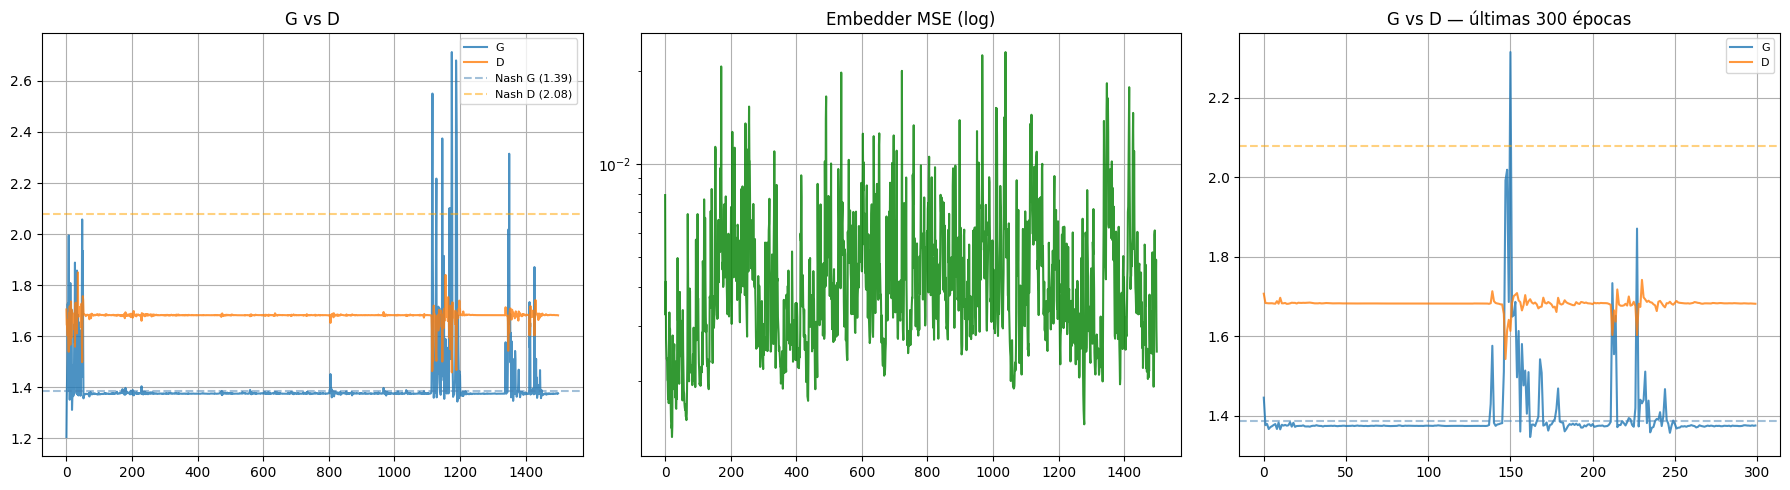

G final: 1.3760 | Nash G: 1.3863 | Gap: 0.0103
D final: 1.6820 | Nash D: 2.0794
Spikes G>3.5: 0

ℹ️  Revisar curva visualmente


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(joint_g_history, label="G", alpha=0.8)
axes[0].plot(joint_d_history, label="D", alpha=0.8)
axes[0].axhline(y=nash_g, color='steelblue', linestyle='--', alpha=0.5, label=f"Nash G ({nash_g:.2f})")
axes[0].axhline(y=nash_d, color='orange',    linestyle='--', alpha=0.5, label=f"Nash D ({nash_d:.2f})")
axes[0].set_title("G vs D"); axes[0].legend(fontsize=8); axes[0].grid(True)

axes[1].semilogy(joint_e_history, color="green", alpha=0.8)
axes[1].set_title("Embedder MSE (log)"); axes[1].grid(True)

axes[2].plot(joint_g_history[-300:], label="G", alpha=0.8)
axes[2].plot(joint_d_history[-300:], label="D", alpha=0.8)
axes[2].axhline(y=nash_g, color='steelblue', linestyle='--', alpha=0.5)
axes[2].axhline(y=nash_d, color='orange',    linestyle='--', alpha=0.5)
axes[2].set_title("G vs D — últimas 300 épocas")
axes[2].legend(fontsize=8); axes[2].grid(True)
plt.tight_layout(); plt.show()

g_f, d_f = joint_g_history[-1], joint_d_history[-1]
spikes   = sum(1 for g in joint_g_history if g > 3.5)
print(f"G final: {g_f:.4f} | Nash G: {nash_g:.4f} | Gap: {abs(g_f - nash_g):.4f}")
print(f"D final: {d_f:.4f} | Nash D: {nash_d:.4f}")
print(f"Spikes G>3.5: {spikes}")
print()

# Diagnóstico
if abs(g_f - nash_g) < 0.2 and d_f > 1.7:
    print("✅  G y D cerca del Nash — balance adversarial correcto")
elif g_f < 1.0:
    print("⚠️  G demasiado bajo — generador dominando (dead eq. como v9)")
    print("   Considerar subir gamma a 0.7")
elif g_f > 2.5:
    print("⚠️  G demasiado alto — discriminador dominando")
    print("   Considerar bajar D lr a 5e-5")
else:
    print("ℹ️  Revisar curva visualmente")


## Generación y evaluación


In [18]:
n_synth = len(train_windows)
synth_list = []
with torch.no_grad():
    for start in range(0, n_synth, 256):
        end   = min(start + 256, n_synth)
        z     = random_z(end - start, seq_len, latent_dim, device)
        x_hat = recovery(supervisor(generator(z))).cpu().numpy()
        synth_list.append(x_hat)

synth_qt = np.concatenate(synth_list, axis=0)
out_rng  = ((synth_qt < -0.1) | (synth_qt > 1.1)).mean() * 100
print(f"Rango pre-clip: [{synth_qt.min():.4f}, {synth_qt.max():.4f}]")
print(f"Fuera de [-0.1, 1.1]: {out_rng:.2f}%")
synth_qt_clipped = np.clip(synth_qt, 0.0, 1.0)

dm = abs(train_windows.mean() - synth_qt_clipped.mean())
ds = abs(train_windows.std()  - synth_qt_clipped.std())
print(f"Diff medias: {dm:.4f} (v10: 0.0986) | Diff stds: {ds:.4f}")


Rango pre-clip: [0.0323, 1.0387]
Fuera de [-0.1, 1.1]: 0.00%
Diff medias: 0.0240 (v10: 0.0986) | Diff stds: 0.0641


In [19]:
n_gan = len(GAN_CONT_COLS)
synth_qt_flat  = synth_qt_clipped.reshape(-1, n_gan)
synth_gan_phys = qt.inverse_transform(synth_qt_flat).reshape(synth_qt_clipped.shape)

def synthesize_fit_windows(n_windows, window_size, fit_cols, fit_empirical, seed=42):
    rng = np.random.default_rng(seed)
    windows = np.zeros((n_windows, window_size, len(fit_cols)), dtype=np.float32)
    for j, col in enumerate(fit_cols):
        p0 = fit_empirical[col]["p_zero"]
        fo = np.array(fit_empirical[col]["flow_open"], dtype=np.float32)
        for i in range(n_windows):
            state = 0 if rng.random() < p0 else 1
            for t in range(window_size):
                if rng.random() >= 0.97:
                    state = 0 if rng.random() < p0 else 1
                windows[i, t, j] = 0.0 if state == 0 else float(rng.choice(fo))
    return windows

def synthesize_disc_windows(n_windows, window_size, discrete_cols, disc_empirical, seed=42):
    rng = np.random.default_rng(seed)
    windows = np.zeros((n_windows, window_size, len(discrete_cols)), dtype=np.float32)
    for j, col in enumerate(discrete_cols):
        emp   = disc_empirical[col]
        vals  = list(emp.keys()); probs = list(emp.values())
        for i in range(n_windows):
            windows[i, 0, j] = rng.choice(vals, p=probs)
            for t in range(1, window_size):
                windows[i, t, j] = windows[i, t-1, j] if rng.random() < 0.95 else rng.choice(vals, p=probs)
    return windows

synth_fit_raw  = synthesize_fit_windows(n_synth, WINDOW_SIZE, FIT_COLS, fit_empirical, SEED)
synth_disc_raw = synthesize_disc_windows(n_synth, WINDOW_SIZE, discrete_cols, disc_empirical, SEED)

synth_all_phys = np.zeros((n_synth, WINDOW_SIZE, len(continuous_cols)), dtype=np.float32)
for j, col in enumerate(GAN_CONT_COLS):
    synth_all_phys[:, :, continuous_cols.index(col)] = synth_gan_phys[:, :, j]
for j, col in enumerate(FIT_COLS):
    if col in continuous_cols:
        synth_all_phys[:, :, continuous_cols.index(col)] = synth_fit_raw[:, :, j]

synth_for_det = scaler_cont_detector.transform(
    pd.DataFrame(synth_all_phys.reshape(-1, len(continuous_cols)), columns=continuous_cols)
).reshape(synth_all_phys.shape)

print("synth_for_det:", synth_for_det.shape)


d:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but QuantileTransformer was fitted with feature names
  warnings.warn(


synth_for_det: (9460, 60, 23)


In [20]:
def one_hot_ds(disc_array, discrete_cols, discrete_value_maps):
    rows = []
    for t in range(disc_array.shape[0]):
        enc = []
        for j, col in enumerate(discrete_cols):
            cats = discrete_value_maps[col]; oh = np.zeros(len(cats), dtype=np.float32)
            v = disc_array[t, j]
            if v in cats: oh[cats.index(v)] = 1.0
            enc.extend(oh)
        rows.append(enc)
    return np.array(rows, dtype=np.float32)

synth_disc_onehot = np.array([
    one_hot_ds(synth_disc_raw[i], discrete_cols, discrete_value_maps)
    for i in range(synth_disc_raw.shape[0])
], dtype=np.float32)

def summarize_disc(disc_raw, discrete_cols):
    rows = []
    for w in disc_raw:
        feats = {}
        for j, col in enumerate(discrete_cols):
            v = w[:, j]
            feats[f"{col}__mode"]        = pd.Series(v).mode().iloc[0]
            feats[f"{col}__transitions"] = np.sum(v[1:] != v[:-1])
            feats[f"{col}__nunique"]     = len(np.unique(v))
            feats[f"{col}__dominance"]   = pd.Series(v).value_counts(normalize=True).iloc[0]
        rows.append(feats)
    return pd.DataFrame(rows)

synth_disc_summary = summarize_disc(synth_disc_raw, discrete_cols)
X_synth_cont = np.transpose(synth_for_det, (0, 2, 1)).astype(np.float32)
X_synth_disc = synth_disc_summary.values.astype(np.float32)
print("X_synth_cont:", X_synth_cont.shape, "| X_synth_disc:", X_synth_disc.shape)


X_synth_cont: (9460, 23, 60) | X_synth_disc: (9460, 104)


Diff medias: 0.1302 | Diff stds: 0.1389


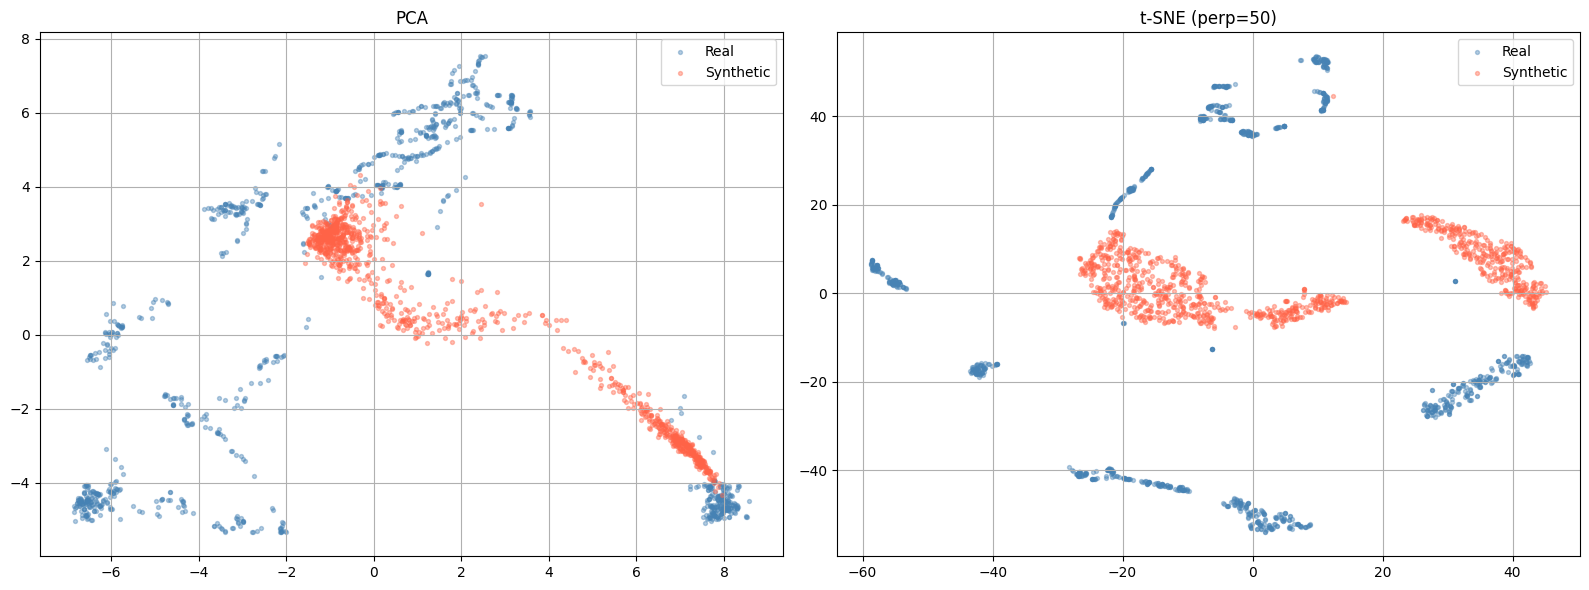

In [22]:
n_plot = min(1000, len(train_windows), n_synth)
rng = np.random.default_rng(SEED)
ri  = rng.choice(len(train_windows),  n_plot, replace=False)
si  = rng.choice(n_synth,             n_plot, replace=False)

real_s  = train_windows[ri].reshape(n_plot, -1)
synth_s = synth_qt_clipped[si].reshape(n_plot, -1)

md = np.abs(real_s.mean(0) - synth_s.mean(0)).mean()
sd = np.abs(real_s.std(0)  - synth_s.std(0)).mean()
print(f"Diff medias: {md:.4f} | Diff stds: {sd:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
pca = PCA(n_components=2, random_state=SEED)
pr  = pca.fit_transform(real_s); ps = pca.transform(synth_s)
axes[0].scatter(pr[:, 0], pr[:, 1], alpha=0.4, c='steelblue', s=8, label="Real")
axes[0].scatter(ps[:, 0], ps[:, 1], alpha=0.4, c='tomato',    s=8, label="Synthetic")
axes[0].set_title("PCA"); axes[0].legend(); axes[0].grid(True)

comb = PCA(n_components=min(50, real_s.shape[1]), random_state=SEED).fit_transform(
    np.vstack([real_s, synth_s])
)
perp = min(50, n_plot // 5)
tout = TSNE(n_components=2, random_state=SEED, perplexity=perp,
            max_iter=2000, init="pca", learning_rate="auto").fit_transform(comb)
axes[1].scatter(tout[:n_plot, 0], tout[:n_plot, 1], alpha=0.4, c='steelblue', s=8, label="Real")
axes[1].scatter(tout[n_plot:, 0], tout[n_plot:, 1], alpha=0.4, c='tomato',    s=8, label="Synthetic")
axes[1].set_title(f"t-SNE (perp={perp})")
axes[1].legend(); axes[1].grid(True)
plt.tight_layout()
plt.savefig("tsne_v11.png", dpi=150, bbox_inches="tight")
plt.show()


In [23]:
X_all = np.vstack([real_s, synth_s])
y_all = np.array([0]*n_plot + [1]*n_plot)
X_tr, X_te, y_tr, y_te = train_test_split(
    X_all, y_all, test_size=0.2, random_state=SEED, stratify=y_all
)
clf = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
clf.fit(X_tr, y_tr)
auc = roc_auc_score(y_te, clf.predict_proba(X_te)[:, 1])

print("=" * 50)
print(f"AUC = {auc:.4f}")
if auc < 0.60:   print("✅  < 0.60 — Alta calidad")
elif auc < 0.75: print("✅  0.60–0.75 — Aceptable para tesis")
elif auc < 0.85: print("⚠️  0.75–0.85 — Mejora clara vs v10 (0.9997)")
else:            print("❌  > 0.85 — Revisar curvas G/D")
print("=" * 50)

fi = clf.feature_importances_
top5 = np.argsort(fi)[-5:][::-1]
print("\nTop 5 features más discriminativas:")
for i in top5:
    ci = i // WINDOW_SIZE; ti = i % WINDOW_SIZE
    print(f"  {GAN_CONT_COLS[ci]} t={ti}: {fi[i]:.4f}")
if fi.max() > 0.10:
    print(f"\n⚠️  Importancia máxima={fi.max():.3f} — revisar distribución de esa feature")
else:
    print(f"\n✅  Importancias distribuidas ({fi.max():.3f} máx)")


AUC = 1.0000
❌  > 0.85 — Revisar curvas G/D

Top 5 features más discriminativas:
  AIT201.Pv t=52: 0.0319
  AIT202.Pv t=6: 0.0283
  AIT201.Pv t=11: 0.0277
  AIT201.Pv t=38: 0.0263
  LIT301.Pv t=2: 0.0250

✅  Importancias distribuidas (0.032 máx)


## Guardado


In [24]:
TIMEGAN_MODEL_DIR = PROJECT_ROOT / "models" / "timegan" / "conv1d_hybrid_aligned"
TIMEGAN_MODEL_DIR.mkdir(parents=True, exist_ok=True)
(PROJECT_ROOT / "artifacts" / "scalers").mkdir(parents=True, exist_ok=True)

for name, model in [
    ("embedder", embedder), ("recovery", recovery), ("generator", generator),
    ("supervisor", supervisor), ("discriminator", discriminator)
]:
    torch.save(model.state_dict(), TIMEGAN_MODEL_DIR / f"{name}.pt")

joblib.dump(qt,                   PROJECT_ROOT / "artifacts" / "scalers" / "timegan_quantile_transformer.pkl")
joblib.dump(scaler_cont_detector, PROJECT_ROOT / "artifacts" / "scalers" / "timegan_scaler_detector.pkl")

with open(TIMEGAN_MODEL_DIR / "fit_empirical.json", "w") as f:
    json.dump({col: {"p_zero": v["p_zero"], "flow_open_sample": v["flow_open"][:500]}
               for col, v in fit_empirical.items()}, f, indent=2)
with open(TIMEGAN_MODEL_DIR / "disc_empirical.json", "w") as f:
    json.dump({k: {str(kk): float(vv) for kk,vv in v.items()} for k,v in disc_empirical.items()}, f, indent=2)
with open(TIMEGAN_MODEL_DIR / "discrete_value_maps.json", "w") as f:
    json.dump({k: [float(v) for v in vs] for k,vs in discrete_value_maps.items()}, f, indent=2)

config = {
    "version": "v11",
    "key_fixes": [
        "stride=2 — más diversidad de datos (mode collapse fix)",
        "Instance noise σ=0.1→0.01 — reemplaza GP (velocidad fix, 8h→20min)",
        "Sin ReduceLROnPlateau — evita dead equilibrium de v9",
        "D_STEPS=1 — equilibrio G/D restaurado"
    ],
    "gan_cont_cols": GAN_CONT_COLS, "fit_cols": FIT_COLS,
    "continuous_cols_detector": continuous_cols, "discrete_cols": discrete_cols,
    "window_size": WINDOW_SIZE, "stride_timegan": TIMEGAN_STRIDE,
    "scaler": "QuantileTransformer(n_quantiles=1000, uniform)",
    "feature_dim": feature_dim, "hidden_dim": hidden_dim,
    "latent_dim": latent_dim, "num_layers": num_layers,
    "G_STEPS": G_STEPS, "D_STEPS": D_STEPS,
    "gamma": gamma, "eta": eta, "FM_WEIGHT": FM_WEIGHT,
    "noise_sigma_init": NOISE_SIGMA_INIT, "noise_sigma_final": NOISE_SIGMA_FINAL,
    "epochs_embedder": epochs_embedder, "epochs_supervisor": epochs_supervisor,
    "epochs_joint": epochs_joint, "batch_size": BATCH_SIZE,
    "train_windows": len(train_windows),
    "embedder_mse": float(embedder_history[-1]),
    "g_final": float(joint_g_history[-1]),
    "d_final": float(joint_d_history[-1]),
    "spikes": int(sum(1 for g in joint_g_history if g > 3.5)),
    "auc": float(auc), "diff_medias": float(md), "diff_stds": float(sd),
}
with open(TIMEGAN_MODEL_DIR / "config.json", "w") as f: json.dump(config, f, indent=4)

np.save(TIMEGAN_MODEL_DIR / "synth_qt.npy",          synth_qt_clipped)
np.save(TIMEGAN_MODEL_DIR / "synth_gan_physical.npy", synth_gan_phys)
np.save(TIMEGAN_MODEL_DIR / "synth_fit_raw.npy",      synth_fit_raw)
np.save(TIMEGAN_MODEL_DIR / "synth_all_physical.npy", synth_all_phys)
np.save(TIMEGAN_MODEL_DIR / "synth_for_detector.npy", synth_for_det)
np.save(TIMEGAN_MODEL_DIR / "synth_disc_raw.npy",     synth_disc_raw)
np.save(TIMEGAN_MODEL_DIR / "synth_disc_onehot.npy",  synth_disc_onehot)
synth_disc_summary.to_csv(TIMEGAN_MODEL_DIR / "synth_disc_summary.csv", index=False)
pd.DataFrame({
    "epoch": range(1, len(joint_g_history)+1),
    "g_loss": joint_g_history, "d_loss": joint_d_history, "e_loss": joint_e_history
}).to_csv(TIMEGAN_MODEL_DIR / "training_history.csv", index=False)

print("✅  Guardado en:", TIMEGAN_MODEL_DIR.resolve())


✅  Guardado en: D:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\models\timegan\conv1d_hybrid_aligned
